### Loading training data

In [1]:
%%time
import os
import json
import sys
from pathlib import Path

import numpy as np

if Path.cwd().name == "plotting":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

from eval.paths import DATA_ROOT

SAVE_DIR = DATA_ROOT
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
qs = targets["qs"]

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)
XMATCH_COLS = meta["XMATCH_COLS"]
NCAT_MATCH = meta["NCAT_MATCH"]

# The experiment split, as eval/splits.py builds it (design 8020) and
# experiment-setup.ipynb saved it. E1/E3 share the match-time population.
SPLIT = np.load(os.path.join(SAVE_DIR, "splits_8020.npz"))
with open(os.path.join(SAVE_DIR, "splits_meta.json")) as f:
    SPLIT_META = json.load(f)

print(f"working directory: {os.getcwd()}")
print(f"Loaded Xmatch {Xmatch.shape} | split {SPLIT_META['design']}, cutoff "
      f"{SPLIT_META['cutoff_utc']}, validation date V {SPLIT_META['val_start_utc']}")

working directory: /home/amaustin/Research/fife-batch-jobs/scripts
Loaded Xmatch (64088358, 42) | split 8020, cutoff 2025-07-10 00:00, validation date V 2025-06-24 00:00
CPU times: user 9.35 s, sys: 195 ms, total: 9.55 s
Wall time: 1.85 s


#### Features

In [2]:
print(f"Xmatch {Xmatch.shape} -- match-time features, shared by E1 and E3:")
for i, nme in enumerate(XMATCH_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: trail*_site/camp/node_fail and *_hw (leak-free trailing failure and")
print("  hardware-fault rates, self-excluded), log_*_running@match (concurrent-running counts)")
print("target: hw_fault -- hardware (1) vs payload (0), defined only for failed jobs")

Xmatch (64088358, 42) -- match-time features, shared by E1 and E3:
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignType
  [ 6] TestLaunch
  [ 7] JobsubGroup
  [ 8] Image
  [ 9] BlacklistSites
  [10] MatchSite
  [11] MatchEntry
  [12] MatchQueue
  [13] MatchResource
  [14] MatchCpus
  [15] RequestCpus (std)
  [16] RequestDisk (std)
  [17] RequestMemory (std)
  [18] RequestSlots (std)
  [19] ExecutableSize (std)
  [20] TransferInputMB (std)
  [21] ExpectedLifetime (std)
  [22] TotalSubmitProcs (std)
  [23] CpusProvisioned (std)
  [24] DiskProvisioned (std)
  [25] MemoryProvisioned (std)
  [26] sin_hour@match
  [27] cos_hour@match
  [28] sin_wday@match
  [29] cos_wday@match
  [30] trail1m_site_fail
  [31] trail60m_site_fail
  [32] trail1m_site_hw
  [33] trail60m_site_hw
  [34] trail1m_camp_fail
  [35] trail60m_camp_fail
  [36] trail60m_node_fail
  [37] trail1440m_node_fail
  [38] trail60m_node_hw
  [39] trail1440m_node_hw
  [40] lo

#### Experiment population: E3 is conditional on failure (E1 → E3)
Failed jobs only, from the 8020 split; each arm's fit / validation / test sets and their hardware share.

In [3]:
# E3 attributes the fault of a job E1 says failed, so its population is the FAILED
# subset of the E1 population. Training: failed jobs in the shared training rows;
# validation: carved from those by the same date rule the harness uses; test: the
# arm's own test set, scored on failed jobs only.
import pandas as pd
from eval.splits import validation_split

V = SPLIT_META["val_start"]
f_ = np.asarray(failed)
hw_ = np.asarray(hw)
train_f = SPLIT["e1e3__train"][f_[SPLIT["e1e3__train"]] == 1]

E3_SETS = {}
rows = []
for arm, test_key in (("random", "e1e3__random_test"), ("temporal", "e1e3__oot_test")):
    fit_i, val_i = validation_split(train_f, arm, qs, V)
    test_i = SPLIT[test_key][f_[SPLIT[test_key]] == 1]
    oot_i = SPLIT["e1e3__oot_test"][f_[SPLIT["e1e3__oot_test"]] == 1]
    E3_SETS[arm] = {"fit": fit_i, "val": val_i, "test": test_i, "oot": oot_i}
    for name, i in E3_SETS[arm].items():
        rows.append({"arm": arm, "set": name, "failed jobs": len(i),
                     "hardware share": hw_[i].mean() if len(i) else np.nan})
pop = pd.DataFrame(rows)
display(pop.style.format({"failed jobs": "{:,}", "hardware share": "{:.2%}"}))
print("The temporal arm's test set is the out-of-time set, so its 'test' and 'oot' rows match.")

,arm,set,failed jobs,hardware share
0,random,fit,"5,173,384",5.50%
1,random,val,"714,124",5.48%
2,random,test,"652,625",5.57%
3,random,oot,"1,494,434",10.89%
4,temporal,fit,"5,173,384",4.96%
5,temporal,val,"714,124",9.37%
6,temporal,test,"1,494,434",10.89%
7,temporal,oot,"1,494,434",10.89%


The temporal arm's test set is the out-of-time set, so its 'test' and 'oot' rows match.


### Loading fault attribution models and feature importances

In [4]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances
from eval.paths import model_dir

# Permutation importance (neural models) and attention mass (TabNet) are measured on a
# random 200,000-job sample of FAILED out-of-time test jobs, scored on hardware vs
# payload -- the population and label E3 is defined on. Tree importances come from the
# saved models themselves (split gain). The same sample is used for both arms' models.
_oot_f = E3_SETS["temporal"]["oot"]
_rng = np.random.default_rng(0)
eval_idx = np.sort(_rng.choice(_oot_f, size=min(200_000, len(_oot_f)), replace=False))
X_eval = np.ascontiguousarray(Xmatch[eval_idx], dtype=np.float32)
y_eval = np.ascontiguousarray(hw_[eval_idx])
print(f"importance sample: {len(eval_idx):,} failed OOT jobs, {y_eval.mean():.2%} hardware")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _models = ["xgboost", "lightgbm", "catboost", "mlp", "tabnet", "saint", "ft", "tsmixer"]
    E3_IMP = load_saved_importances(
        models=_models,
        model_dirs=[model_dir("e3", m, create=False) for m in _models],
        exp_tag=None,
        splits=["random", "temporal"],
        n_feats=len(XMATCH_COLS),
        X_eval=X_eval,
        y_eval=y_eval,
    )

importance sample: 200,000 failed OOT jobs, 10.93% hardware
[Loaded Tree Model] xgboost    (random  ) <- /mnt/scratch/ssd/amaustin/models/e3/xgboost/xgboost_bin_random.json
[Loaded Tree Model] xgboost    (temporal) <- /mnt/scratch/ssd/amaustin/models/e3/xgboost/xgboost_bin_temporal.json
[Loaded Tree Model] lightgbm   (random  ) <- /mnt/scratch/ssd/amaustin/models/e3/lightgbm/lightgbm_bin_random.txt
[Loaded Tree Model] lightgbm   (temporal) <- /mnt/scratch/ssd/amaustin/models/e3/lightgbm/lightgbm_bin_temporal.txt
[Loaded Tree Model] catboost   (random  ) <- /mnt/scratch/ssd/amaustin/models/e3/catboost/catboost_bin_random.txt
[Loaded Tree Model] catboost   (temporal) <- /mnt/scratch/ssd/amaustin/models/e3/catboost/catboost_bin_temporal.txt
[Computed Permutation Imp] mlp        (random  ) on cuda
[Computed Permutation Imp] mlp        (temporal) on cuda
[Loaded TabNet Model] tabnet     (random  ) computed feature importances successfully.
[Loaded TabNet Model] tabnet     (temporal) compute

## Feature Importance
### Random split

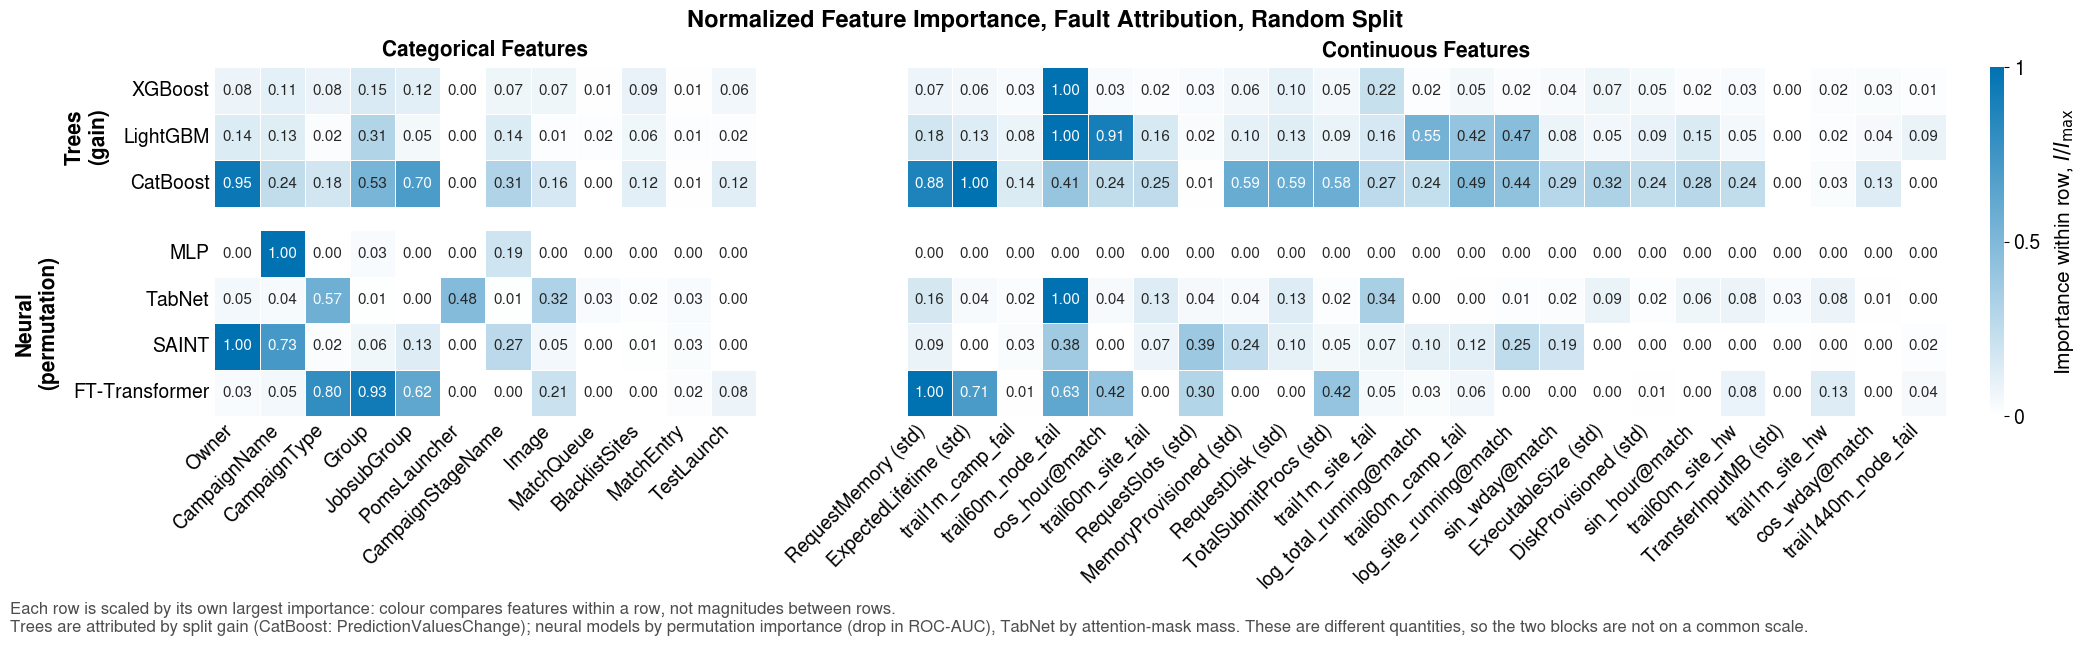

In [5]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E3_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,
    split_key="random",
    title="Normalized Feature Importance, Fault Attribution, Random Split",
    output_prefix="e3_feature_split_imp_heatmap",
)

### Temporal split

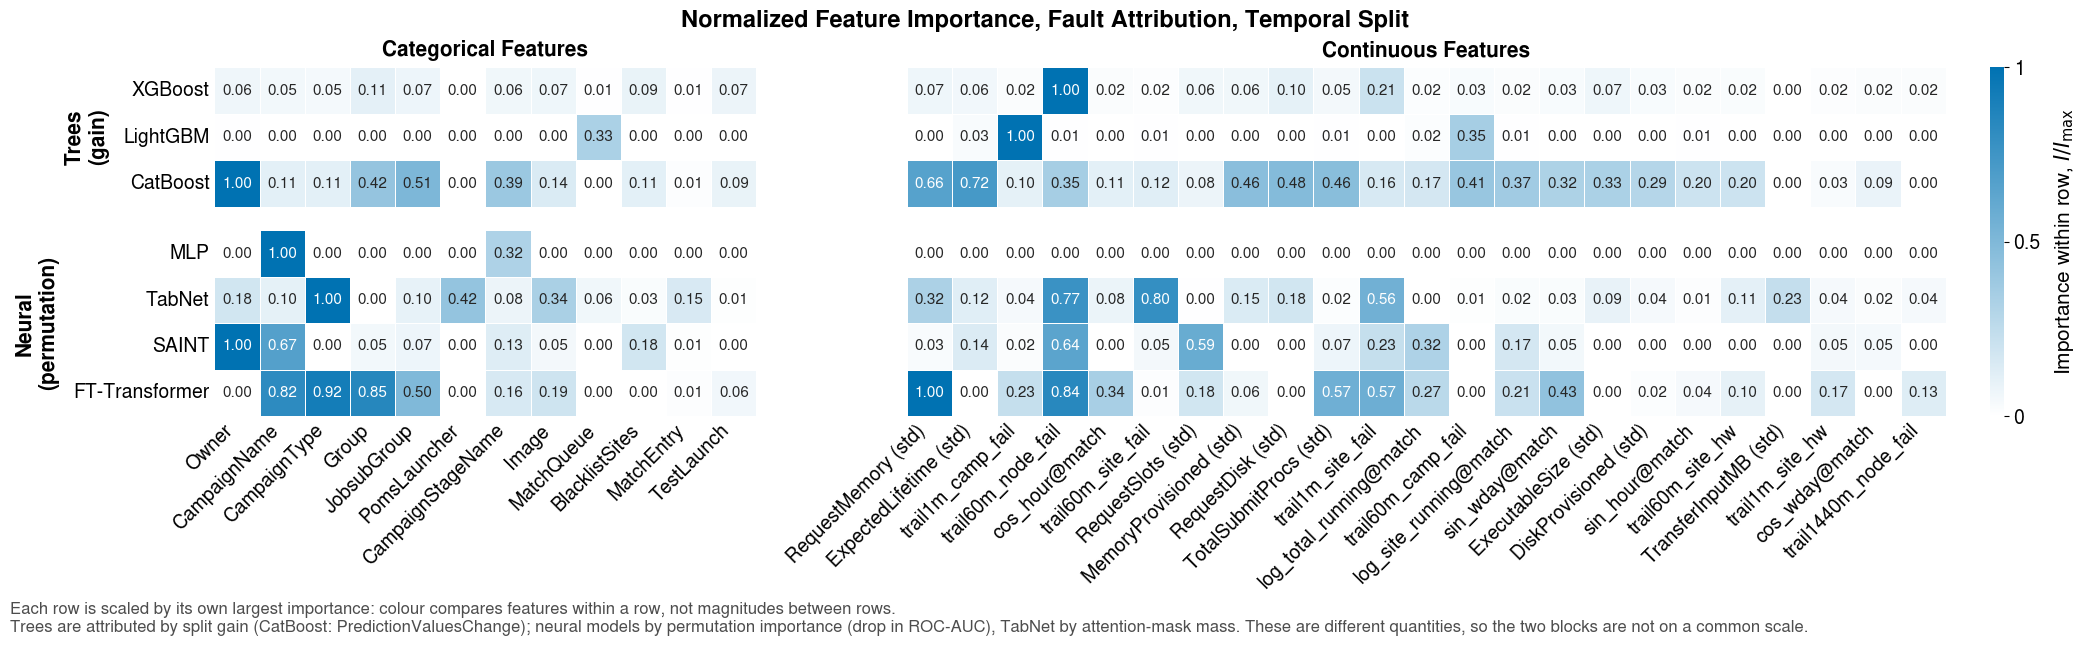

In [6]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E3_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,
    split_key="temporal",
    title="Normalized Feature Importance, Fault Attribution, Temporal Split",
    output_prefix="e3_feature_split_imp_heatmap",
)

### Feature gain shift (random -> temporal)

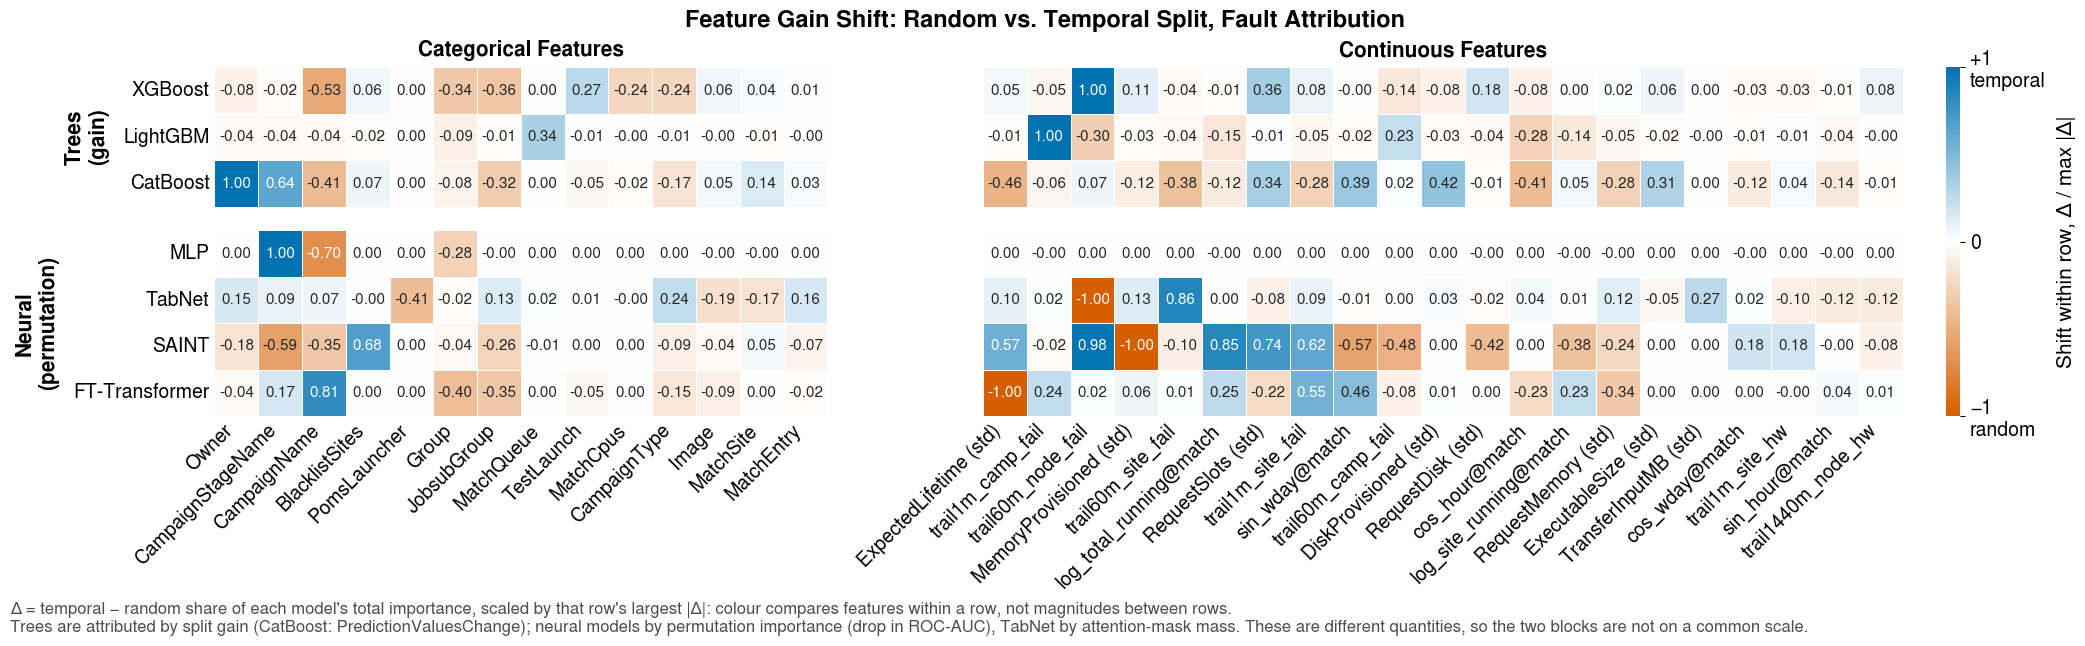

,Owner,CampaignStageName,CampaignName,BlacklistSites,PomsLauncher,Group,JobsubGroup,MatchQueue,TestLaunch,MatchCpus,...,RequestDisk (std),cos_hour@match,log_site_running@match,RequestMemory (std),ExecutableSize (std),TransferInputMB (std),cos_wday@match,trail1m_site_hw,sin_hour@match,trail1440m_node_hw
XGBoost,-0.079937,-0.020625,-0.532093,0.059522,0.000000,-0.343063,-0.358319,0.003231,0.268080,-0.244766,...,1.765244e-01,-0.083336,0.002659,0.019169,0.062662,0.000000e+00,-0.033827,-0.033919,-0.009713,0.075609
LightGBM,-0.037739,-0.042258,-0.037906,-0.018449,0.000000,-0.093151,-0.014325,0.335510,-0.005292,-0.000005,...,-3.815356e-02,-0.277795,-0.137476,-0.054503,-0.015695,-7.837780e-11,-0.009860,-0.005094,-0.038701,-0.000917
CatBoost,1.000000,0.636022,-0.414614,0.067066,0.000000,-0.076073,-0.319167,0.004375,-0.050914,-0.017364,...,-1.294769e-02,-0.411223,0.051409,-0.279827,0.306664,0.000000e+00,-0.119154,0.035083,-0.135010,-0.009516
MLP,0.000000,1.000000,-0.699858,0.000000,0.000000,-0.279571,-0.003608,0.000000,0.000014,0.000000,...,-9.291779e-07,0.000022,-0.003602,-0.000001,0.000000,0.000000e+00,-0.000006,0.000004,-0.003575,0.000000
TabNet,0.152539,0.091117,0.066022,-0.001342,-0.412999,-0.019729,0.134249,0.019987,0.006994,-0.000438,...,-2.061481e-02,0.041536,0.007012,0.119406,-0.048533,2.670482e-01,0.018774,-0.099437,-0.117950,-0.120805
SAINT,-0.175557,-0.585510,-0.351369,0.681098,0.000000,-0.040843,-0.260009,-0.007478,0.000000,0.000000,...,-4.184844e-01,0.000000,-0.376032,-0.241900,0.000000,9.225112e-04,0.181255,0.176159,-0.004900,-0.078432
FT-Transformer,-0.044996,0.168655,0.805341,0.000000,0.000000,-0.404256,-0.345964,0.000844,-0.047249,0.000794,...,0.000000e+00,-0.225575,0.226574,-0.339564,0.000000,2.341452e-04,0.000000,-0.003165,0.042785,0.010359


In [7]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

# One table, each row scaled by its own max |delta|. Trees and neural models sit in
# separate row blocks: split gain and permutation importance are different quantities,
# so the per-row scaling does not put them on a common footing (see the figure note).
imp_diff_heatmap(
    imp_dict=E3_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,
    per_model_scale=False,
    title="Feature Gain Shift: Random vs. Temporal Split, Fault Attribution",
    output_prefix="e3_imp_diff_heatmap",
)

## Performance evaluation
Seed-averaged results from the harness (`results/fault_attr/<model>.json`).

In [2]:
# The harness saves every E3 run's results -- each arm's own test set and the shared
# out-of-time set -- in results/fault_attr/<model>.json, with predictions on disk, so
# nothing is re-evaluated here. Mean +/- SD over the seeded runs.
import json
import pandas as pd
from eval.helper import aggregate_seeds

from eval.helper import load_results
E3_RESULTS = load_results("fault_attr")

MODEL_NAMES = {"xgboost": "XGBoost", "lightgbm": "LightGBM", "catboost": "CatBoost",
               "mlp": "MLP", "tabnet": "TabNet", "saint": "SAINT",
               "ft": "FT-Transformer", "tsmixer": "TSMixer"}
COLS = ["roc_auc", "hardware.pr_auc", "hardware.f1", "payload.pr_auc", "payload.f1", "mcc"]
rows = []
for mk, name in MODEL_NAMES.items():
    if mk not in E3_RESULTS:
        continue
    for arm, block, label in (("random", "", "Random, Random"), ("random", "oot.", "Random, OOT"),
                              ("temporal", "oot.", "Temporal, OOT")):
        runs = [v for k, v in E3_RESULTS[mk].items() if k.startswith(f"{arm}__seed")]
        if not runs:
            continue
        agg = aggregate_seeds(runs)
        rec = {"model": name, "arm": label, "seeds": len(runs)}
        for c in COLS:
            b = agg.get(block + c)
            rec[c] = f"{b['mean']:.3f} ± {b['std']:.3f}" if b else ""
        rows.append(rec)
summary = pd.DataFrame(rows)
display(summary) if len(summary) else print("no seeded E3 results yet")

,model,arm,seeds,roc_auc,hardware.pr_auc,hardware.f1,payload.pr_auc,payload.f1,mcc
0,XGBoost,"Random, Random",3,0.995 ± 0.000,0.926 ± 0.001,0.850 ± 0.001,1.000 ± 0.000,0.990 ± 0.000,0.842 ± 0.001
1,XGBoost,"Random, OOT",3,0.699 ± 0.021,0.261 ± 0.007,0.177 ± 0.005,0.953 ± 0.005,0.945 ± 0.000,0.212 ± 0.015
2,XGBoost,"Temporal, OOT",3,0.689 ± 0.020,0.185 ± 0.010,0.163 ± 0.029,0.953 ± 0.003,0.920 ± 0.002,0.070 ± 0.021
3,LightGBM,"Random, Random",3,0.978 ± 0.000,0.637 ± 0.003,0.780 ± 0.002,0.997 ± 0.000,0.983 ± 0.000,0.784 ± 0.002
4,LightGBM,"Random, OOT",3,0.587 ± 0.030,0.146 ± 0.015,0.256 ± 0.040,0.908 ± 0.006,0.898 ± 0.010,0.159 ± 0.038
5,LightGBM,"Temporal, OOT",3,0.564 ± 0.003,0.134 ± 0.002,0.223 ± 0.005,0.904 ± 0.001,0.904 ± 0.006,0.128 ± 0.007
6,CatBoost,"Random, Random",1,0.972 ± 0.000,0.569 ± 0.000,0.727 ± 0.000,0.997 ± 0.000,0.978 ± 0.000,0.737 ± 0.000
7,CatBoost,"Random, OOT",1,0.563 ± 0.000,0.133 ± 0.000,0.220 ± 0.000,0.903 ± 0.000,0.903 ± 0.000,0.123 ± 0.000
8,CatBoost,"Temporal, OOT",1,0.542 ± 0.000,0.121 ± 0.000,0.191 ± 0.000,0.899 ± 0.000,0.873 ± 0.000,0.071 ± 0.000


### Performance evaluation (hardware vs payload), conditional on failure

Random, Random    652,625 failed jobs | hardware  5.57%
Random, OOT     1,494,434 failed jobs | hardware 10.89%
Temporal, OOT   1,494,434 failed jobs | hardware 10.89%

   model            arm  n hardware.pr_auc roc_auc hardware.f1   mcc
 XGBoost Random, Random  3           0.926   0.995       0.850 0.842
 XGBoost    Random, OOT  3           0.261   0.699       0.177 0.212
 XGBoost  Temporal, OOT  3           0.185   0.689       0.163 0.070
LightGBM Random, Random  3           0.637   0.978       0.780 0.784
LightGBM    Random, OOT  3           0.146   0.587       0.256 0.159
LightGBM  Temporal, OOT  3           0.134   0.564       0.223 0.128
CatBoost Random, Random  1           0.569   0.972       0.727 0.737
CatBoost    Random, OOT  1           0.133   0.563       0.220 0.123
CatBoost  Temporal, OOT  1           0.121   0.542       0.191 0.071


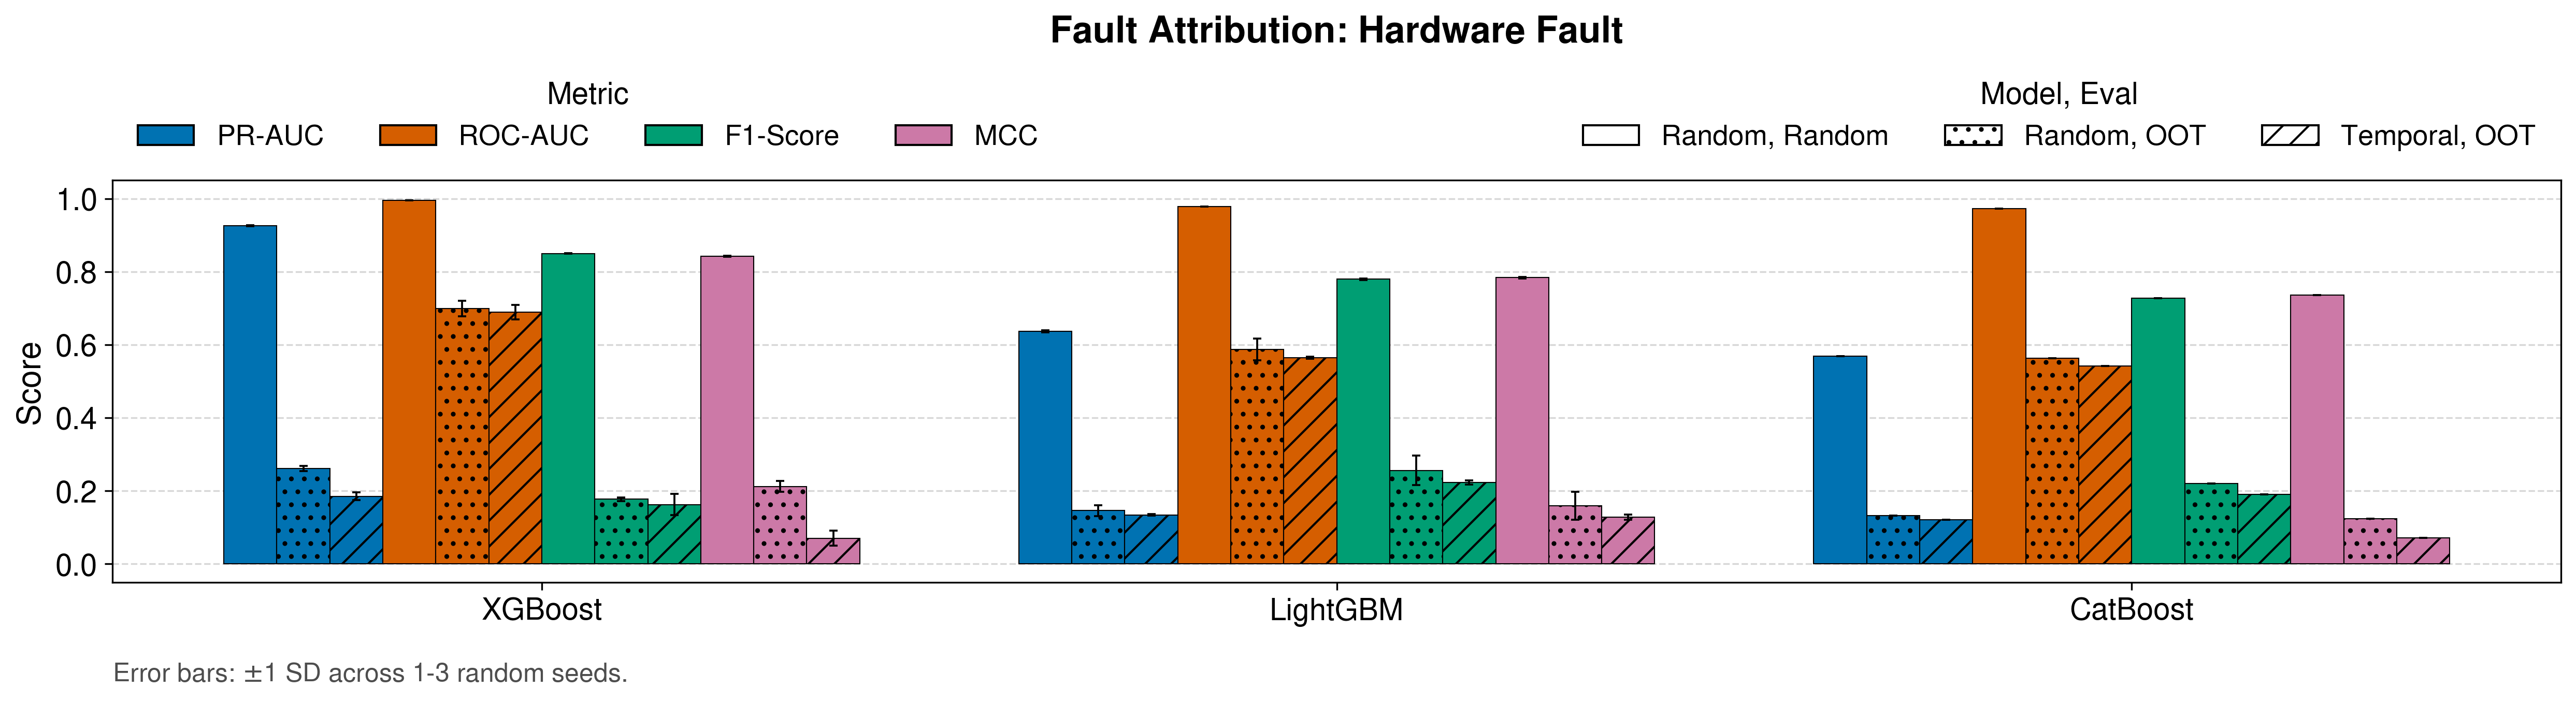

Saved /home/amaustin/Research/fife-batch-jobs/scripts/output/e3_fault_attribution_hardware.pdf


In [3]:
# E3 hardware chart: hardware is the positive class, scored at its own tuned threshold.
METRICS = [
    ("hardware.pr_auc",    "PR-AUC"),
    ("roc_auc",   "ROC-AUC"),
    # ("hardware.precision", "Precision"),
    # ("hardware.recall",    "Recall"),
    ("hardware.f1",        "F1-Score"),
    ("mcc",                "MCC"),
]
# (training split, label, hatch, metric prefix). Both out-of-time arms read the shared
# OOT slice ("oot."), the August jobs neither arm trained on, so the two are scored on
# identical rows. The temporal split's own test set (July) is what the paper table uses.
PROTOCOLS = [
    ("random",   "Random, Random", "",   ""),
    ("random",   "Random, OOT",    "..", "oot."),
    ("temporal", "Temporal, OOT",  "//", "oot."),
]
CLASSES = [("hardware", "Hardware Fault")]
# ----------------------------------------------------------------------------------

# E3 answers "given that this job failed, which kind of fault was it?" -- every number
# here is CONDITIONAL on failure; the cascade gives the full-population figure.
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from eval.helper import aggregate_seeds
from eval.style import SERIES

from eval.helper import load_results
MODEL_ORDER = {"xgboost": "XGBoost", "lightgbm": "LightGBM", "catboost": "CatBoost",
               "mlp": "MLP", "tabnet": "TabNet", "saint": "SAINT",
               "ft": "FT-Transformer", "tsmixer": "TSMixer"}

results = load_results("fault_attr")   # results/fault_attr/<model>.json
model_keys = [k for k in MODEL_ORDER if k in results]


def stat(mkey, split, metric):
    """Mean, SD and n over the seeded runs of this model/split. The plain `<split>` key
    is skipped: it is an older single run from before the shared OOT slice, scored on a
    different test set, and averaging it in skews both the bar and its error bar."""
    runs = [v for k, v in results[mkey].items() if k.startswith(f"{split}__seed")]
    b = aggregate_seeds(runs).get(metric) if runs else None
    return (b["mean"], b["std"], b["n"]) if b else (np.nan, 0.0, 0)


# Test-set sizes and class rates per arm, for the notes and the printed table.
_ref = model_keys[0]
ARM_INFO = {}
for pkey, plabel, _h, mpref in PROTOCOLS:
    n, _, _ = stat(_ref, pkey, mpref + "n_test")
    ARM_INFO[plabel] = {"n": n, "hardware": stat(_ref, pkey, f"{mpref}hardware.prevalence")[0]}
for plabel, info in ARM_INFO.items():
    print(f"{plabel:15s} {int(info['n']):>9,} failed jobs | hardware "
          f"{info['hardware'] * 100:5.2f}%")

# ------------------------------------------------------------------ table
rows = []
for mk in model_keys:
    for pkey, plabel, _h, mpref in PROTOCOLS:
        rec = {"model": MODEL_ORDER[mk], "arm": plabel}
        for m, _l in METRICS:
            mu, sd, n = stat(mk, pkey, mpref + m)
            rec[m], rec["n"] = mu, n
        rows.append(rec)
table = pd.DataFrame(rows)
_cols = [m for m, _ in METRICS]
print()
print(table[["model", "arm", "n"] + _cols].to_string(
    index=False, formatters={c: "{:.3f}".format for c in _cols}))

# ------------------------------------------------------------------ figures
FONT = 14
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Nimbus Sans",
    "font.size": FONT,
    "axes.labelsize": FONT + 1,
    "axes.titlesize": FONT + 3,
    "xtick.labelsize": FONT,
    "ytick.labelsize": FONT,
    "legend.fontsize": FONT - 1,
    "legend.title_fontsize": FONT,
})
models = [MODEL_ORDER[k] for k in model_keys]
n_bars = len(METRICS) * len(PROTOCOLS)
w = 0.8 / n_bars
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w
x = np.arange(len(models))
os.makedirs(os.path.join(os.getcwd(), "output"), exist_ok=True)

for cls, clabel in CLASSES:
    fig, ax = plt.subplots(figsize=(max(13, 1.4 * n_bars), 5), dpi=300)
    seed_counts, i, _lo = set(), 0, 0.0
    for _mi, (mkey, _l) in enumerate(METRICS):
        for pkey, _pl, hatch, mpref in PROTOCOLS:
            vals, errs = [], []
            for k in model_keys:
                mu, sd, n = stat(k, pkey, mpref + mkey)
                vals.append(mu); errs.append(sd); seed_counts.add(n)
                _lo = min(_lo, mu - sd) if np.isfinite(mu) else _lo
            ax.bar(x + offsets[i], vals, w, color=SERIES[_mi % len(SERIES)],
                   edgecolor="black", linewidth=0.5, hatch=hatch,
                   # +/-1 SD across seeds; absent when every seed reproduced exactly.
                   yerr=errs if any(e > 0 for e in errs) else None,
                   error_kw=dict(ecolor="black", elinewidth=0.9, capsize=2, capthick=0.9),
                   zorder=3)
            i += 1

    ax.set_ylabel("Score")
    ax.set_xticks(x); ax.set_xticklabels(models)
    # MCC can be negative; drop the floor below zero only when a bar needs it.
    ax.set_ylim(min(0.0, _lo - 0.05), 1.05)
    if _lo < 0:
        ax.axhline(0, color="black", linewidth=0.8, zorder=2)
    ax.grid(axis="y", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
    ax.set_title(f"Fault Attribution: {clabel}", pad=64,
                 fontweight="bold")

    ns = sorted(n for n in seed_counts if n)
    rng_txt = f"{min(ns)}" + (f"-{max(ns)}" if min(ns) != max(ns) else "")
    note = (f"Error bars: $\\pm$1 SD across {rng_txt} random seeds.")
    ax.annotate(note, xy=(0, -0.2), xycoords="axes fraction", fontsize=FONT - 2,
                ha="left", va="top", color="0.30")

    leg1 = ax.legend(handles=[Patch(facecolor=SERIES[j % len(SERIES)], edgecolor="black",
                                    label=l) for j, (_, l) in enumerate(METRICS)],
                     title="Metric", loc="lower left", bbox_to_anchor=(0.0, 1.01),
                     ncol=len(METRICS), frameon=False, alignment="center")
    ax.add_artist(leg1)
    ax.legend(handles=[Patch(facecolor="white", edgecolor="black", hatch=h, label=l)
                       for _, l, h, _p in PROTOCOLS],
              title="Model, Eval", loc="lower right", bbox_to_anchor=(1.0, 1.01),
              ncol=len(PROTOCOLS), frameon=False, alignment="center")

    plt.tight_layout()
    stem = os.path.join(os.getcwd(), f"output/e3_fault_attribution_{cls}")
    plt.savefig(stem + ".pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved {stem}.pdf")


#### E3: Temporal vs Random on the out-of-time test set -- seed consistency

The first cell computes `results/oot_significance.csv` (paired bootstrap); the second plots it.

In [7]:
# Paired bootstrap of temporal minus random on the out-of-time test set, per model and
# metric (eval.helper.oot_protocol_significance). Uses every model's saved predictions
# and only the seeds both arms have finished. Several minutes; set RECOMPUTE = True
# after results/fault_attr/<model>.json changes. Writes results/oot_significance.csv,
# which the next cell plots.
import os
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import oot_protocol_significance

SIG_PATH = "results/oot_significance.csv"
RECOMPUTE = not os.path.exists(SIG_PATH)

if RECOMPUTE:
    sig = oot_protocol_significance("e3", n_boot=1000, n_jobs=24)
    sig.to_csv(SIG_PATH, index=False)
    print(f"wrote {SIG_PATH}: {len(sig)} rows, models {sorted(sig['model'].unique())}")
else:
    print(f"{SIG_PATH} exists -- set RECOMPUTE = True to rebuild it")

[significance] Poisson bootstrap on cuda:0


wrote results/oot_significance.csv: 18 rows, models ['CatBoost', 'LightGBM', 'XGBoost']


wrote results/oot_significance.csv: 18 rows, models ['CatBoost', 'LightGBM', 'XGBoost']


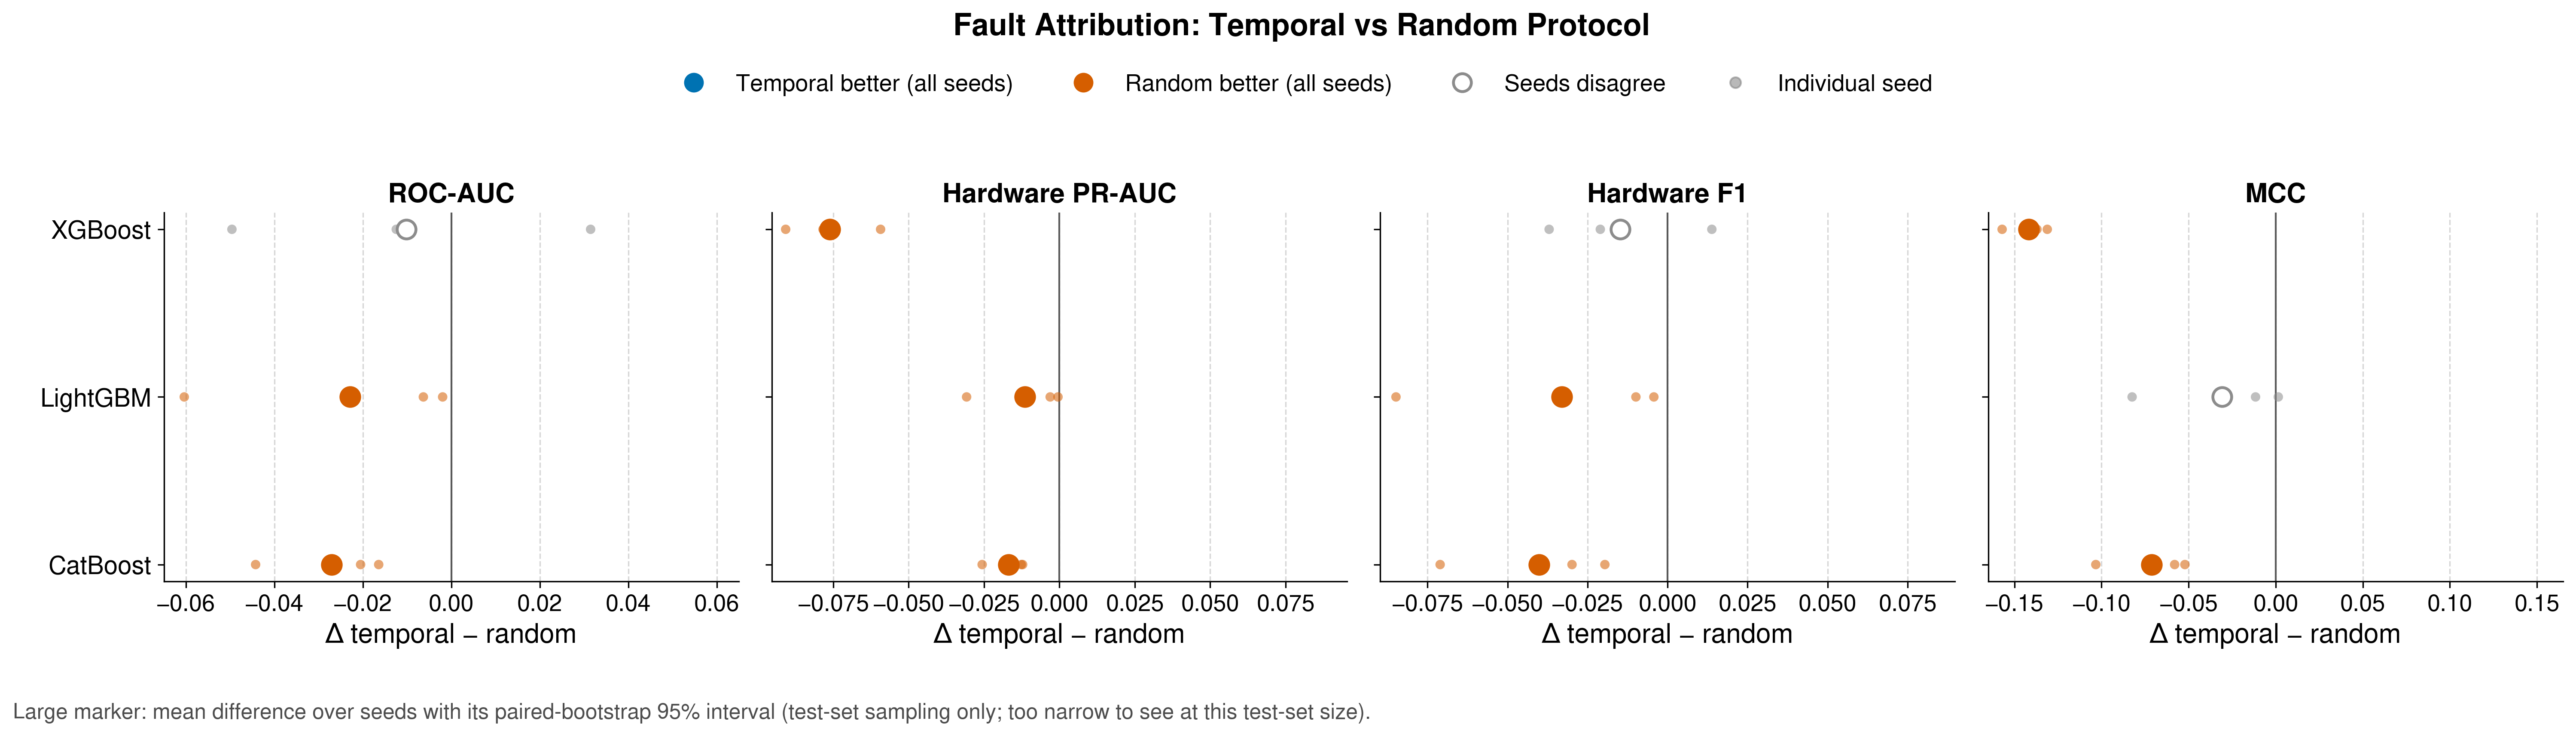

In [8]:
# Temporal vs Random on the shared out-of-time test set: is the difference consistent?
# Each row is one model. Small dots are the three seeds' differences (temporal - random,
# both arms scored on the identical out-of-time failed jobs); the large marker is their mean
# with the paired-bootstrap 95% interval from results/oot_significance.csv
# (eval.helper.oot_protocol_significance). At ~746k test jobs that interval is
# hair-thin, so the seeds -- not the interval -- show whether a difference is real.
PANELS = [
    ("roc_auc",         "ROC-AUC"),
    ("hardware.pr_auc", "Hardware PR-AUC"),
    ("hardware.f1",     "Hardware F1"),
    ("mcc",             "MCC"),             # at the hardware threshold, as stored
]
SIG_CSV = "results/oot_significance.csv"
# ----------------------------------------------------------------------------------
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from eval.style import COLORS

MODEL_ORDER = {"xgboost": "XGBoost", "lightgbm": "LightGBM", "catboost": "CatBoost",
               "mlp": "MLP", "tabnet": "TabNet", "saint": "SAINT",
               "ft": "FT-Transformer", "tsmixer": "TSMixer"}
from eval.helper import load_results
results = load_results("fault_attr")
sig = pd.read_csv(SIG_CSV)
model_keys = [k for k in MODEL_ORDER if k in results]


def _get(run, path):
    for p in path.split("."):
        run = run[p]
    return float(run)


def seed_deltas(mk, metric):
    """Temporal minus random, per seed, both read from each run's OOT block."""
    out = []
    for k, run in results[mk].items():
        if k.startswith("temporal__seed"):
            rk = k.replace("temporal", "random", 1)
            if rk in results[mk]:
                out.append(_get(run["oot"], metric) - _get(results[mk][rk]["oot"], metric))
    return np.array(out)


# Direction colours follow the paper's split colours; seeds that disagree are neutral.
C_TEMP, C_RAND, C_MIXED = COLORS["primary"], COLORS["secondary"], "#8C8C8C"

FONT = 14
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": "Nimbus Sans",
    "font.size": FONT, "axes.labelsize": FONT + 1, "axes.titlesize": FONT + 1,
    "xtick.labelsize": FONT - 1, "ytick.labelsize": FONT,
    "legend.fontsize": FONT - 1,
})

fig, axes = plt.subplots(1, len(PANELS), figsize=(5 * len(PANELS), 5.2), sharey=True,
                         dpi=300)
y = np.arange(len(model_keys))[::-1]          # first model at the top
for ax, (metric, label) in zip(axes, PANELS):
    for yi, mk in zip(y, model_keys):
        d = seed_deltas(mk, metric)
        row = sig[(sig.model == MODEL_ORDER[mk]) & (sig.metric == metric)]
        mean = float(row["delta"].iloc[0]) if len(row) else float(d.mean())
        agree = np.all(np.sign(d) == np.sign(mean)) and mean != 0
        col = (C_TEMP if mean > 0 else C_RAND) if agree else C_MIXED
        ax.scatter(d, np.full(len(d), yi), s=28, color=col, alpha=0.55,
                   edgecolor="none", zorder=3)
        if len(row):
            ax.hlines(yi, row["ci_lo"].iloc[0], row["ci_hi"].iloc[0], color="0.2",
                      linewidth=2, zorder=4)
        ax.scatter([mean], [yi], s=110, zorder=5, linewidth=1.6,
                   facecolor=col if agree else "white", edgecolor=col)
    ax.axvline(0, color="0.35", linewidth=1, zorder=2)
    ax.set_title(label, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    lim = max(abs(v) for v in ax.get_xlim())
    ax.set_xlim(-lim, lim)                     # symmetric, so zero sits in the middle
    ax.set_xlabel("Δ temporal − random")
axes[0].set_yticks(y); axes[0].set_yticklabels([MODEL_ORDER[k] for k in model_keys])

handles = [
    Line2D([], [], marker="o", linestyle="", markersize=10, color=C_TEMP,
           label="Temporal better (all seeds)"),
    Line2D([], [], marker="o", linestyle="", markersize=10, color=C_RAND,
           label="Random better (all seeds)"),
    Line2D([], [], marker="o", linestyle="", markersize=10, markerfacecolor="white",
           markeredgecolor=C_MIXED, markeredgewidth=1.6, label="Seeds disagree"),
    Line2D([], [], marker="o", linestyle="", markersize=6, color="0.5", alpha=0.55,
           label="Individual seed"),
]
# Title, then legend, then panels: tight_layout keeps the panels below the rect top.
fig.suptitle("Fault Attribution: Temporal vs Random Protocol",
             fontweight="bold", fontsize=FONT + 3, y=0.99)
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.93))
fig.text(0.0, -0.04,
         "Large marker: mean difference over seeds with its paired-bootstrap 95% interval "
         "(test-set sampling only; too narrow to see at this test-set size).",
         ha="left", va="top", fontsize=FONT - 2, color="0.30")
plt.tight_layout(rect=(0, 0, 1, 0.86))
os.makedirs("output", exist_ok=True)
plt.savefig("output/e3_oot_significance.pdf", bbox_inches="tight")
plt.show()
